In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [2]:
# load data
X =np.load('data/f3/updated_inputs.npy') #seems already normalized
y=np.load('data/f3/updated_outputs.npy') #negative values to maximize 

In [3]:
# compute mean distance between data
distances = pdist(X, metric='euclidean')

In [4]:
# The current best
best_f = np.max(y)
best_idx = np.argmax(y)
print(f"Best current value: X = {X[best_idx]}, y = {best_f:.4f}")

Best current value: X = [0.49258141 0.61159319 0.34017639], y = -0.0348


In [5]:
# Grid 3D for evaluation
from scipy.stats import qmc

dim=3
n_grid = 5000 
sampler = qmc.LatinHypercube(d=dim, seed=42)
sample = sampler.random(n=n_grid)

# Compute boundaries
l_bounds = X.min(axis=0)  
u_bounds = X.max(axis=0)  
x_grid_d = qmc.scale(sample, l_bounds, u_bounds)

In [6]:
# EI
xi = 0.1
def expected_improvement(mean, std, best_f, xi):
    Z  = (mean - best_f - xi) / (std + 1e-9)
    ei = (mean - best_f - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= 0.0] = 0.0
    return ei

In [7]:
# find the optimal lengthscale
noise_assumption = 1e-4
Alpha=[]
Mean=[]
STD=[]
for alpha in np.linspace(0.1, 3, 30):
    rbf_lengthscale  = alpha*distances.mean()#alpha times mean distance

    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
    model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
    model.fit(X, y)

    # GP prediction ---
    post_mean, post_std = model.predict(x_grid_d, return_std=True)
    ei_values = expected_improvement(post_mean, post_std, best_f, xi)

    # The next point
    idx_next  = np.argmax(ei_values)# simple grid
    x_next    = x_grid_d[idx_next]
    Alpha.append(alpha)
    Mean.append(post_mean[idx_next])
    STD.append(post_std[idx_next])

Alpha for max mean= 0.8999999999999999


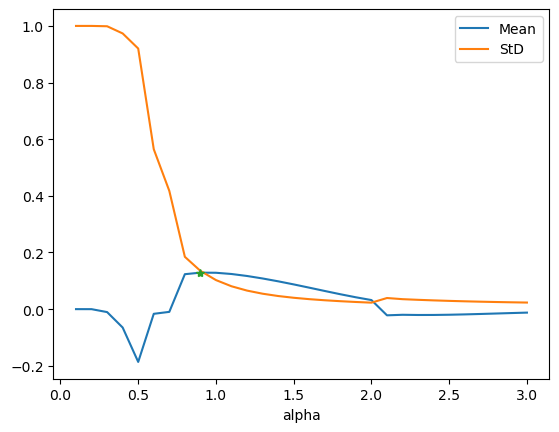

In [8]:
# plot alpha optimization
id_max = np.argmax(Mean)
plt.plot(Alpha,Mean, label='Mean')
plt.plot(Alpha,STD, label='StD')
plt.plot(Alpha[id_max], Mean[id_max], marker='*')
plt.xlabel('alpha')
plt.legend()

print('Alpha for max mean=',Alpha[id_max])

In [9]:
# re-compute maximum
alpha=Alpha[id_max]
rbf_lengthscale  = alpha*distances.mean()#max mean distance
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
model.fit(X, y)
#GP Prediction
post_mean, post_std = model.predict(x_grid_d, return_std=True)
ei_values = expected_improvement(post_mean, post_std, best_f, xi)

#Next Point from EI
idx_next = np.argmax(ei_values)
x_next   = x_grid_d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]#Next Point

print(f"Suggested query (EI): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}, x3={x_next[2]:.8f}")
print('mean next=',post_mean[idx_next])
print('std next=',post_std[idx_next])

#query from EI
x_next_ei = x_next
y_next_ei = y_next

Suggested query (EI): x1=0.49609050, x2=0.22321758, x3=0.65421820
mean next= 0.12883669868082825
std next= 0.1350775823549181


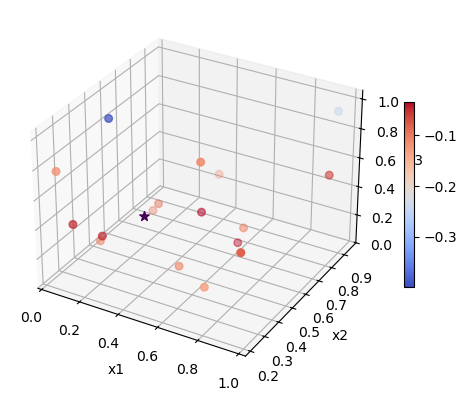

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
p3d = ax.scatter(X[:,0], X[:,1], X[:,2], s=30, c=y, cmap = cm.coolwarm)
# Added: Create colorbar to show the scale of y values
ax.scatter(x_grid_d[idx_next,0], x_grid_d[idx_next,1], x_grid_d[idx_next,2], c=post_mean[idx_next], marker='*', s=50)
plt.colorbar(p3d, ax=ax, shrink=0.5, aspect=20)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
plt.show()

In [11]:
# UCB acquisition: best k
K=[]
Mean=[]
STD=[]
for k in np.linspace(0.1, 3, 30):
    #UCB (maximize)
    acquisition = post_mean + k * post_std
    idx_next = np.argmax(acquisition)
    x_next = x_grid_d[idx_next]
    K.append(k)
    Mean.append(post_mean[idx_next])
    STD.append(post_std[idx_next])

K for max mean= 0.1


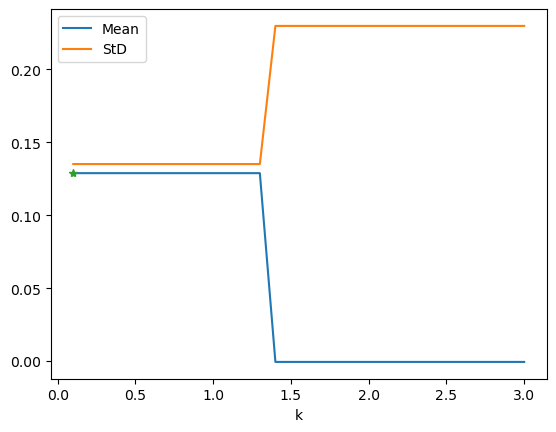

In [12]:
# plot k optimization
id_max = np.argmax(Mean)
plt.plot(K,Mean, label='Mean')
plt.plot(K,STD, label='StD')
plt.plot(K[id_max], Mean[id_max], marker='*')
plt.xlabel('k')
plt.legend()

print('K for max mean=',K[id_max])

In [13]:
# re-compute maximum
acquisition = post_mean + K[id_max] * post_std
idx_next = np.argmax(acquisition)
x_next = x_grid_d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]
    
print(f"Proposed query (UCB): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}, x3={x_next[2]:.8f}")
print('mean next=',post_mean[idx_next])
print('std next=',post_std[idx_next])

#query from UCB
x_next_ucb = x_next
y_next_ucb = y_next

Proposed query (UCB): x1=0.49609050, x2=0.22321758, x3=0.65421820
mean next= 0.12883669868082825
std next= 0.1350775823549181


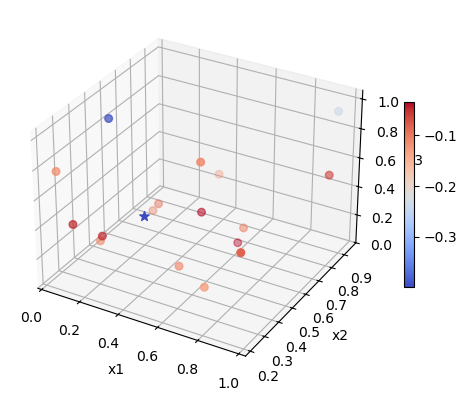

In [14]:
# graph
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
p3d = ax.scatter(X[:,0], X[:,1], X[:,2], s=30, c=y, cmap = cm.coolwarm)
# Added: Create colorbar to show the scale of y values
ax.scatter(x_grid_d[idx_next,0], x_grid_d[idx_next,1], x_grid_d[idx_next,2], c=post_mean[idx_next], marker='*', s=50, cmap = cm.coolwarm)
plt.colorbar(p3d, ax=ax, shrink=0.5, aspect=20)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
plt.show()


In [15]:
# RSM Method
import pandas as pd
from statsmodels.formula.api import ols

In [16]:
# create dataframe
data = np.column_stack((X,y))
df = pd.DataFrame(data, columns=['x1', 'x2', 'x3', 'y'])
# fit regression model
model = ols(formula='y ~ x1 + x2 + x3 + I(x1**2) + I(x2**2) + I(x3**2)', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     3.170
Date:                Sun, 13 Sep 2026   Prob (F-statistic):             0.0521
Time:                        11:08:15   Log-Likelihood:                 26.793
No. Observations:                  17   AIC:                            -39.59
Df Residuals:                      10   BIC:                            -33.75
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2095      0.169     -1.242      0.2

In [17]:
# Optimization (Gradient Descent - Simplified)
from scipy.optimize import minimize

def objective(Xin):
    x1, x2, x3 = Xin
    return -model.predict(pd.DataFrame({'x1': [x1], 'x2': [x2], 'x3': [x3]}))[0]

initial_guess = [0.1, 0.1, 0.1]
result = minimize(objective, initial_guess, bounds=[(0, 1.), (0, 1.), (0, 1.)], method='L-BFGS-B')
optimal = result.x
print('optimal=',optimal)
print('objective (y)=',-objective(optimal))

#query from RSM
x_next_rsm = optimal
y_next_rsm = -objective(optimal)

optimal= [0.64990682 0.         0.4228    ]
objective (y)= -0.02575198621013157


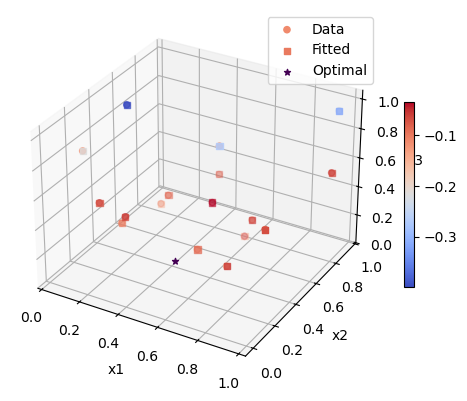

In [18]:
# Analyse the response surface and optimal
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
p3d=ax.scatter(df['x1'], df['x2'], df['x3'], c=df['y'], marker='o', label='Data', cmap = cm.coolwarm)
ax.scatter(df['x1'], df['x2'], df['x3'], c=model.fittedvalues, marker='s', label='Fitted', cmap = cm.coolwarm)
ax.scatter(optimal[0], optimal[1], optimal[2], c=-objective(optimal), marker='*', label='Optimal')
plt.colorbar(p3d, ax=ax, shrink=0.5, aspect=20)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.legend(loc='best')
plt.show()


In [19]:
# Choose the best option between EI, UCB and RSM
if y_next_ei >= y_next_ucb and y_next_ei >= y_next_rsm:
    x_next_out = x_next_ei
elif y_next_ucb > y_next_ei and y_next_ucb > y_next_rsm:
    x_next_out = x_next_ucb
else:
    x_next_out = x_next_rsm

# Write output file
import os
folder = 'results'
filename = 'output_F3.txt'
file_path = os.path.join(folder, filename)
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(f"{x_next_out[0]:.6f} {x_next_out[1]:.6f} {x_next_out[2]:.6f}\n")